In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("Placement.csv")

In [3]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [4]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [5]:
dataset.fillna(0,inplace=True)

In [6]:
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

In [7]:
#to_merge_dataset=[df1,df2] --> combine two dataframes
#pd.concat(to_merge_dataset, axis=1) -->join with column wise

dataset.to_csv("PrePlacement.csv",index=False)

In [8]:
preprocessed=pd.read_csv("PrePlacement.csv")

In [9]:
preprocessed

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [10]:
import seaborn as sns

C:\Users\sethu\AppData\Local\Temp\ipykernel_4936\40979546.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['ssc_p'])


<Axes: xlabel='ssc_p', ylabel='Density'>

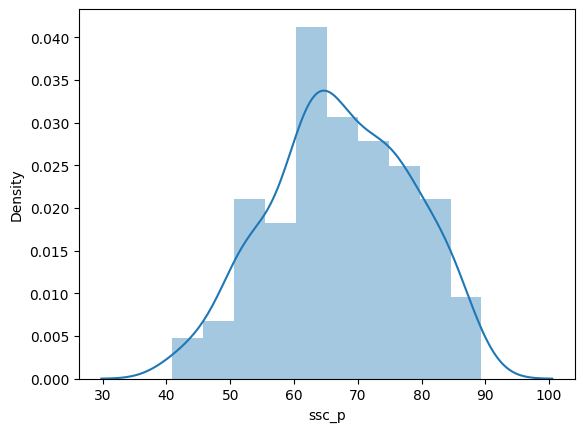

In [11]:
sns.distplot(dataset['ssc_p'])

In [12]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    sns.histplot(dataset, color='lightgreen', stat='density')  # histogram as density
    sns.kdeplot(dataset, color='blue')  # KDE curve
    #ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green') #this is depecreated due to that used histplot(),displot()
    pyplot.axvline(startrange,color='Red') #draw a vertical line
    pyplot.axvline(endrange,color='Red') #draw a vertical line
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
      
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)] #it holds list of values ex:[61,62,..,69]
    probabilities = [dist.pdf(value) for value in values]    #it holds list of calculated 'pdf' value
    prob=sum(probabilities) #sum of all calculated pdf values from the list
    print("The area between range({},{}):{:.3f}".format(startrange,endrange,sum(probabilities)))
    return prob
    

Mean=67.303, Standard Deviation=10.827
The area between range(60,70):0.345


np.float64(0.3449514151280293)

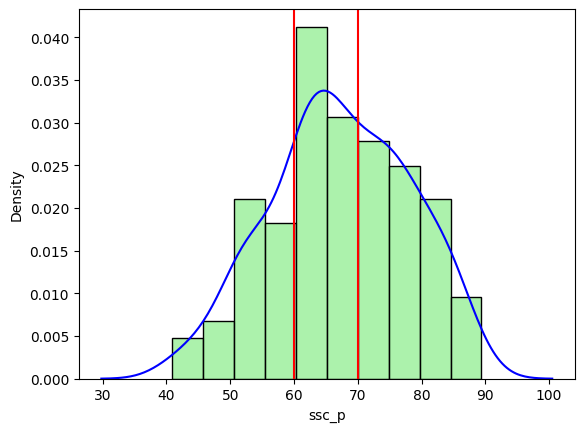

In [13]:
get_pdf_probability(dataset["ssc_p"],60,70) #passed 'ssc_p' column to find the probability that lie between 60 and 70.Based on the fitted normal distribution, about 34% of the data is expected in this interval.

# CUMULATIVE DISTRIBUTION FUNCTION

In [14]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset['ssc_p']) #ECDF reflects the true shape of the provided data
ecdf(78)

np.float64(0.827906976744186)

In [ ]:
# !pip install statsmodels

# STANDARD NORMAL DISTRIBUTION

In [15]:
def convertNormalDistToStdNormalDist(dataset):
    import seaborn as sns
    import numpy as np
    
    mean=dataset.mean() #calculate mean of dataset
    std=dataset.std() #calculate std of dataset
    
    z_score = [((x-mean)/std) for x in dataset] #Formula Z-Score=((x-mean)/std). In line for loop is used
    
    print("Mean:", round(np.mean(z_score), 5)) #calculated mean of z_score using numpy(should be approximately 0)
    print("Std:", round(np.std(z_score), 5)) #calculated std of z_score using numpy(should be approximately 1)
    
    sns.histplot(z_score, color='lightgreen', stat='density')  # histogram as density
    sns.kdeplot(z_score, color='blue')  # KDE curve

Mean: -0.0
Std: 0.99767


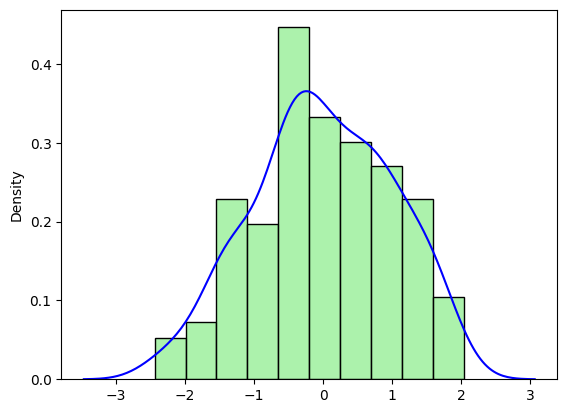

In [16]:
convertNormalDistToStdNormalDist(dataset['ssc_p'])